##Setup

In [1]:
!pip install gymnasium shimmy ale-py
!pip install autorom
!AutoROM -y

AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/adventure.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/air_raid.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/alien.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/amidar.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/assault.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asterix.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/asteroids.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/atlantis2.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/backgammon.bin
Installed /usr/local/lib/python3.12/dist-packages/AutoROM/roms/bank_heist.bin
Inst

In [2]:
"""
live_plot.py — drop-in live metrics dashboard for Go-Explore notebooks.

Usage
-----
from live_plot import MetricsDashboard

dashboard = MetricsDashboard(metrics=['max_reward', 'cells', 'loss', 'entropy'])

# inside your training loop, replace print(...) with:
dashboard.update(
    iteration   = iterations,
    frames      = frames,
    max_reward  = highscore,
    cells       = len(archive),
    loss        = loss,
    entropy     = entropy,   # omit kwargs that don't apply to your algorithm
)
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from IPython import display as ipydisplay
from collections import defaultdict
import numpy as np

# ── Aesthetic config ──────────────────────────────────────────────────────────
BG       = '#0d1117'
PANEL_BG = '#161b22'
GRID_COL = '#21262d'
TEXT     = '#e6edf3'
MUTED    = '#8b949e'
BORDER   = '#30363d'

PALETTE = [
    '#58a6ff',   # blue       — max_reward
    '#3fb950',   # green      — cells
    '#f78166',   # red-orange — loss
    '#d2a8ff',   # lavender   — entropy
    '#ffa657',   # amber      — actor_loss
    '#79c0ff',   # light blue — critic_loss
]

# Human-readable labels for known metric keys
LABELS = {
    'max_reward'  : 'Max Reward',
    'cells'       : 'Archive Cells',
    'loss'        : 'Loss',
    'entropy'     : 'Entropy',
    'actor_loss'  : 'Actor Loss',
    'critic_loss' : 'Critic Loss',
    'epsilon'     : 'Epsilon',
    'frames'      : 'Frames',
}


class MetricsDashboard:
    """
    Live-updating matplotlib dashboard for Jupyter notebooks.

    Parameters
    ----------
    metrics : list[str]
        Names of the metrics to plot, e.g. ['max_reward', 'cells', 'loss'].
        Each gets its own subplot panel.
    title : str
        Dashboard title shown at the top.
    update_every : int
        Redraw the figure every N calls to .update(). Higher = faster training,
        less smooth graph. Default 1 redraws every iteration.
    window : int | None
        If set, only the last `window` iterations are shown (rolling view).
        None shows the full history.
    """

    def __init__(
        self,
        metrics       : list,
        title         : str  = 'Go-Explore Training',
        update_every  : int  = 1,
        window        : int | None = None,
    ):
        if not metrics:
            raise ValueError('Provide at least one metric name.')

        self.metrics      = metrics
        self.title        = title
        self.update_every = update_every
        self.window       = window
        self._call_count  = 0

        # History stores: iteration index + one list per metric
        self._iters : list[int]            = []
        self._data  : dict[str, list[float]] = defaultdict(list)

        matplotlib.rcParams.update({
            'font.family'      : 'monospace',
            'axes.facecolor'   : PANEL_BG,
            'figure.facecolor' : BG,
            'text.color'       : TEXT,
            'axes.labelcolor'  : MUTED,
            'xtick.color'      : MUTED,
            'ytick.color'      : MUTED,
            'axes.edgecolor'   : BORDER,
            'axes.grid'        : True,
            'grid.color'       : GRID_COL,
            'grid.linewidth'   : 0.6,
            'axes.spines.top'  : False,
            'axes.spines.right': False,
        })

        n    = len(metrics)
        cols = min(n, 2)
        rows = (n + 1) // 2

        self._fig = plt.figure(
            figsize    = (7 * cols, 3.2 * rows + 0.8),
            facecolor  = BG,
        )

        # Title row + metric panels
        outer = gridspec.GridSpec(
            2, 1,
            figure       = self._fig,
            height_ratios= [0.18, 1],
            hspace       = 0.05,
        )
        inner = gridspec.GridSpecFromSubplotSpec(
            rows, cols,
            subplot_spec = outer[1],
            hspace       = 0.55,
            wspace       = 0.35,
        )

        # Header panel (text only)
        self._header_ax = self._fig.add_subplot(outer[0])
        self._header_ax.axis('off')
        self._title_text = self._header_ax.text(
            0.5, 0.45, title,
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=15, fontweight='bold',
            color=TEXT, fontfamily='monospace',
        )
        self._subtitle_text = self._header_ax.text(
            0.5, -0.25, '',
            transform = self._header_ax.transAxes,
            ha='center', va='center',
            fontsize=9, color=MUTED, fontfamily='monospace',
        )

        # One subplot per metric
        self._axes = []
        self._lines = []
        for idx, metric in enumerate(metrics):
            row, col = divmod(idx, cols)
            ax = self._fig.add_subplot(inner[row, col])
            ax.set_title(
                LABELS.get(metric, metric),
                fontsize=10, color=MUTED,
                pad=6, loc='left',
            )
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
            ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
            ax.tick_params(labelsize=7)

            color = PALETTE[idx % len(PALETTE)]
            (line,) = ax.plot([], [], color=color, linewidth=1.6, antialiased=True)

            # Subtle fill under the curve
            ax.fill_between([], [], color=color, alpha=0.08)

            self._axes.append(ax)
            self._lines.append(line)

        # Hide any unused subplot slots
        for idx in range(len(metrics), rows * cols):
            row, col = divmod(idx, cols)
            self._fig.add_subplot(inner[row, col]).set_visible(False)

        plt.close(self._fig)   # Don't show yet; we control display manually

    # ─────────────────────────────────────────────────────────────────────────
    def update(self, iteration: int, frames: int = 0, **metric_values):
        """
        Record one data point and optionally redraw.

        Parameters
        ----------
        iteration : int
            Current training iteration (x-axis).
        frames : int
            Total environment frames so far (shown in subtitle).
            If 'frames' is also listed in the `metrics` list passed to
            __init__, it will be plotted as a panel too — the named parameter
            and the plottable metric are the same value.
        **metric_values
            Keyword arguments matching the `metrics` list passed to __init__.
            Unknown keys are silently ignored.
        """
        # FIX: 'frames' is an explicit named parameter used for the subtitle,
        # so passing frames=N never reaches **metric_values — it gets consumed
        # by the signature before ** sees it. If the user listed 'frames' as a
        # metric to plot, inject it back into the lookup dict here.
        if 'frames' in self.metrics:
            metric_values = {**metric_values, 'frames': frames}

        self._iters.append(iteration)
        for metric in self.metrics:
            value = metric_values.get(metric, float('nan'))
            self._data[metric].append(float(value))

        self._call_count += 1
        if self._call_count % self.update_every == 0:
            self._redraw(frames)

    # ─────────────────────────────────────────────────────────────────────────
    def _redraw(self, frames: int):
        iters = np.array(self._iters)

        if self.window is not None and len(iters) > self.window:
            iters = iters[-self.window:]
            data  = {m: self._data[m][-self.window:] for m in self.metrics}
        else:
            data = self._data

        # Update subtitle
        latest = {m: data[m][-1] for m in self.metrics if data[m]}
        parts  = [f'iter {iters[-1]:,}', f'frames {frames:,}']
        parts += [f"{LABELS.get(m, m)}: {v:.3g}" for m, v in latest.items()]
        #self._subtitle_text.set_text('  ·  '.join(parts))

        for ax, line, metric in zip(self._axes, self._lines, self.metrics):
            y = np.array(data[metric], dtype=float)

            # Remove old fill_between collections and redraw
            for coll in ax.collections:
                coll.remove()

            line.set_data(iters, y)

            color = line.get_color()
            ax.fill_between(iters, y, alpha=0.08, color=color)

            # Tight axis limits with padding
            valid = y[np.isfinite(y)]
            if len(valid) >= 2:
                ymin, ymax = valid.min(), valid.max()
                pad = (ymax - ymin) * 0.12 or 0.5
                ax.set_ylim(ymin - pad, ymax + pad)

            if len(iters) >= 2:
                ax.set_xlim(iters[0], iters[-1])

        ipydisplay.clear_output(wait=True)
        ipydisplay.display(self._fig)

    def final(self):
        """Call once at the end of training to ensure the final state is shown."""
        self._redraw(frames=self._iters[-1] if self._iters else 0)

def get_lives(env):
    """
    Read the current number of lives directly from the ALE emulator,
    bypassing the Gymnasium wrapper entirely.

    Why this matters:
    - Montezuma's Revenge reports info['lives'] as lives *remaining after
      the current one*, so a fresh episode starts at 5, not 6.
    - Checking `info['lives'] < 6` is therefore always True, terminating
      every episode on step 1 and freezing archive growth at ~8 cells.
    - After ale.restoreState() the wrapper's internal counter is stale
      (it only updates through env.reset()), making info['lives'] wrong
      for the entire restored episode too.
    - env.unwrapped.ale.lives() always reflects the true ALE state
      regardless of how the state was set.

    Usage pattern in training loop:
        current_lives = get_lives(env)          # after reset or restore
        ...
        new_lives = get_lives(env)              # after env.step()
        life_lost = new_lives < current_lives   # relative decrease only
        current_lives = new_lives
    """
    return env.unwrapped.ale.lives()

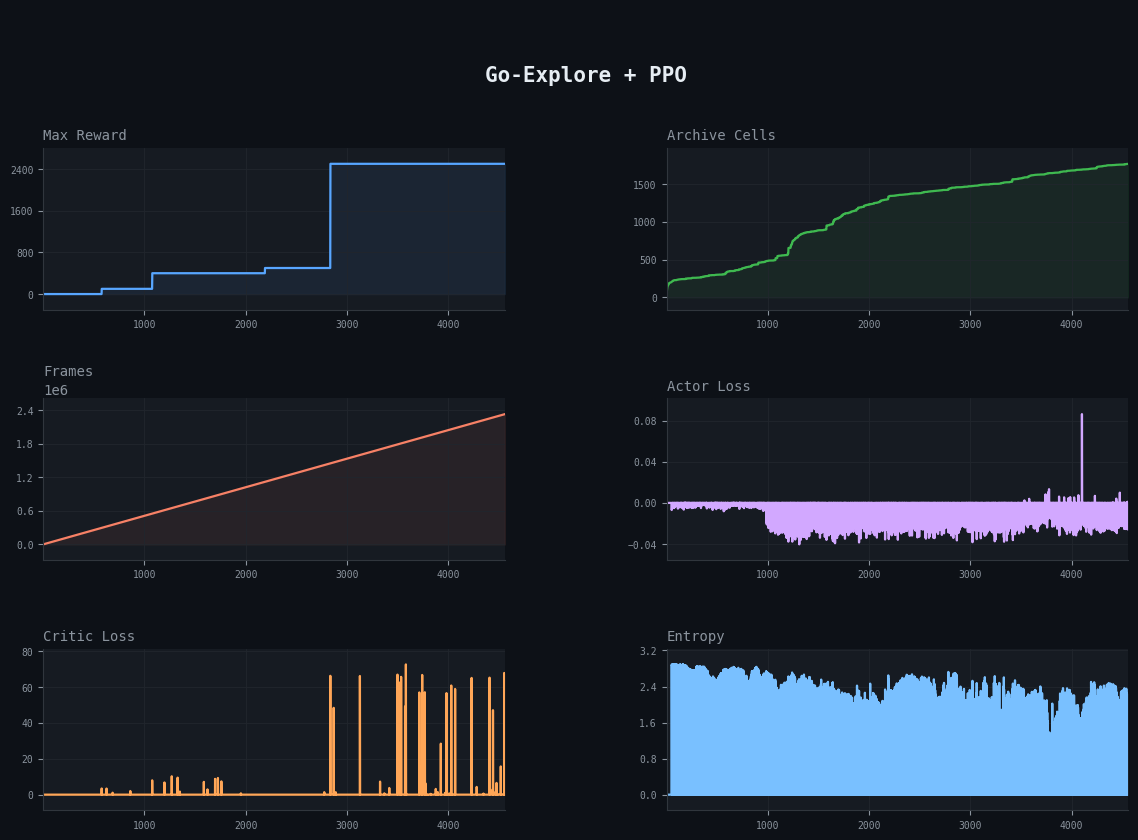

In [ ]:
from collections import defaultdict
import numpy as np
import cv2
import gymnasium as gym
import ale_py
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

dashboard = MetricsDashboard(
    metrics=['max_reward', 'cells', 'frames', 'actor_loss', 'critic_loss', 'entropy'],
    title='Go-Explore + PPO', update_every=10,
)

# ──────────────────────────────────────────────
# Go-Explore cell functions (pixel-based)
# ──────────────────────────────────────────────
def cellfn(frame):
    cell = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    cell = cv2.resize(cell, (11, 8), interpolation=cv2.INTER_AREA)
    cell = cell // 32
    return cell

def hashfn(cell):
    return hash(cell.tobytes())

# ──────────────────────────────────────────────
# Go-Explore archive
# ──────────────────────────────────────────────
e1 = 0.001
e2 = 0.00001

class Weights:
    times_chosen           = 0.1
    times_chosen_since_new = 0.0
    times_seen             = 0.3

class Powers:
    times_chosen           = 0.5
    times_chosen_since_new = 0.5
    times_seen             = 0.5

class Cell:
    def __init__(self):
        self.times_chosen           = 0
        self.times_chosen_since_new = 0
        self.times_seen             = 0

    def __setattr__(self, key, value):
        object.__setattr__(self, key, value)
        if key != 'score' and hasattr(self, 'times_seen'):
            self.score = self.cellscore()

    def cntscore(self, a):
        w = getattr(Weights, a)
        p = getattr(Powers, a)
        v = getattr(self, a)
        return w / (v + e1) ** p + e2

    def cellscore(self):
        return (self.cntscore('times_chosen') +
                self.cntscore('times_chosen_since_new') +
                self.cntscore('times_seen') + 1)

    def visit(self):
        self.times_seen += 1
        return self.times_seen == 1

    def choose(self):
        self.times_chosen           += 1
        self.times_chosen_since_new += 1
        return self.ram, self.reward, self.trajectory


# ──────────────────────────────────────────────
# Actor-Critic Network (shared backbone)
# ──────────────────────────────────────────────
class ActorCritic(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),             nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),             nn.ReLU(),
        )
        with torch.no_grad():
            feature_size = self.conv(
                torch.zeros(1, *input_shape)
            ).reshape(1, -1).size(1)

        self.shared_fc   = nn.Sequential(nn.Linear(feature_size, 512), nn.ReLU())
        self.actor_head  = nn.Linear(512, n_actions)
        self.critic_head = nn.Linear(512, 1)

    def forward(self, x):
        x        = x.float() / 255.
        features = self.conv(x).reshape(x.size(0), -1)
        shared   = self.shared_fc(features)
        return self.actor_head(shared), self.critic_head(shared)

    def get_action_and_value(self, x):
        logits, value = self(x)
        dist   = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), value.squeeze(-1)

    def evaluate_actions(self, x, actions):
        logits, value = self(x)
        dist      = torch.distributions.Categorical(logits=logits)
        return dist.log_prob(actions), dist.entropy(), value.squeeze(-1)


# ──────────────────────────────────────────────
# PPO Agent
# ──────────────────────────────────────────────
class PPOAgent:
    def __init__(
        self, env,
        lr            = 2.5e-4,
        gamma         = 0.99,
        gae_lambda    = 0.95,
        clip_eps      = 0.1,
        ppo_epochs    = 4,
        mini_batches  = 4,
        entropy_coef  = 0.01,
        value_coef    = 0.5,
        grad_clip     = 0.5,
        normalize_adv = True,
    ):
        obs              = env.observation_space.shape
        self.input_shape = (obs[2], obs[0], obs[1])
        self.n_actions   = env.action_space.n

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f'Using device: {self.device}')

        self.net       = ActorCritic(self.input_shape, self.n_actions).to(self.device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=lr, eps=1e-5)

        self.gamma        = gamma
        self.gae_lambda   = gae_lambda
        self.clip_eps     = clip_eps
        self.ppo_epochs   = ppo_epochs
        self.mini_batches = mini_batches
        self.entropy_coef = entropy_coef
        self.value_coef   = value_coef
        self.grad_clip    = grad_clip
        self.normalize_adv = normalize_adv

    def preprocess(self, state):
        return torch.from_numpy(state).permute(2, 0, 1).unsqueeze(0).to(self.device)

    def select_action(self, state):
        with torch.no_grad():
            action, log_prob, _, value = self.net.get_action_and_value(
                self.preprocess(state)
            )
        return action.item(), log_prob.item(), value.item()

    def get_value(self, state):
        with torch.no_grad():
            _, value = self.net(self.preprocess(state))
        return value.item()

    def compute_gae(self, rewards, values, dones, last_value):
        T          = len(rewards)
        advantages = torch.zeros(T, device=self.device)
        gae        = 0.0
        next_value = last_value

        for t in reversed(range(T)):
            non_terminal = 1.0 - dones[t]
            delta  = rewards[t] + self.gamma * next_value * non_terminal - values[t]
            gae    = delta + self.gamma * self.gae_lambda * non_terminal * gae
            advantages[t] = gae
            next_value    = values[t]

        returns = advantages + torch.tensor(values, dtype=torch.float32,
                                            device=self.device)
        return advantages, returns

    def update(self, rollout):
        states_t  = torch.from_numpy(
            np.array(rollout['states'])
        ).permute(0, 3, 1, 2).to(self.device)
        actions_t = torch.tensor(rollout['actions'],   dtype=torch.long).to(self.device)
        old_lps_t = torch.tensor(rollout['log_probs'], dtype=torch.float32).to(self.device)

        advantages, returns = self.compute_gae(
            rollout['rewards'], rollout['values'],
            rollout['dones'],   rollout['last_value']
        )

        T          = len(rollout['states'])
        batch_size = max(1, T // self.mini_batches)

        total_al = total_cl = total_ent = n = 0

        for _ in range(self.ppo_epochs):
            for start in range(0, T, batch_size):
                idx = torch.randperm(T, device=self.device)[start : start + batch_size]
                if len(idx) < 2:
                    continue

                mb_adv = advantages[idx]
                if self.normalize_adv:
                    mb_adv = (mb_adv - mb_adv.mean()) / (mb_adv.std() + 1e-8)

                new_lps, entropy, new_vals = self.net.evaluate_actions(
                    states_t[idx], actions_t[idx]
                )
                ratio      = torch.exp(new_lps - old_lps_t[idx])
                surr1      = ratio * mb_adv
                surr2      = torch.clamp(ratio, 1 - self.clip_eps,
                                                1 + self.clip_eps) * mb_adv
                actor_loss  = -torch.min(surr1, surr2).mean()
                critic_loss = F.huber_loss(new_vals, returns[idx].detach(), delta=1.0)
                loss        = (actor_loss
                               + self.value_coef  * critic_loss
                               - self.entropy_coef * entropy.mean())

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.net.parameters(), self.grad_clip)
                self.optimizer.step()

                total_al  += actor_loss.item()
                total_cl  += critic_loss.item()
                total_ent += entropy.mean().item()
                n         += 1

        d = max(n, 1)
        return total_al / d, total_cl / d, total_ent / d


# ──────────────────────────────────────────────
# State restoration
# ──────────────────────────────────────────────
def restore_env(env, ram):
    env.unwrapped.ale.restoreState(ram)
    return env.unwrapped.ale.getScreenRGB()


# ──────────────────────────────────────────────
# Hyperparameters
# ──────────────────────────────────────────────
WARMUP_ITERS    = 50
STEPS_PER_ITER  = 512   # PPO collects a fixed number of steps, NOT one episode.
                        # Longer rollouts give GAE more signal and the archive
                        # more steps to discover new cells. This is a key
                        # difference from A2C/DQN/ACER which broke on episode end.
EXPLORE_EPSILON = 0.5

archive      = defaultdict(lambda: Cell())
highscore    = 0
frames       = 0

env   = gym.make('ALE/MontezumaRevenge-v5', render_mode='rgb_array')
agent = PPOAgent(env)

state, _      = env.reset()
score         = 0
trajectory    = []
iterations    = 0
restore_cell  = None
current_lives = get_lives(env)

# ──────────────────────────────────────────────
# Main loop
# ──────────────────────────────────────────────
while True:
    found_new_cell = False

    rollout = {
        'states'    : [],
        'actions'   : [],
        'log_probs' : [],
        'rewards'   : [],
        'values'    : [],
        'dones'     : [],
        'last_value': 0.0,
    }

    # Decide once per rollout: random (Go-Explore) or policy (PPO)
    use_random = iterations < WARMUP_ITERS or random.random() < EXPLORE_EPSILON

    # ── Collect a FIXED-LENGTH rollout (no break on episode end) ─────────────
    #
    # This is the critical difference from the other algorithms in this repo.
    # A2C/DQN/ACER used `break` when an episode ended, giving ~9 steps per
    # iteration on average (since the untrained policy dies quickly). PPO is
    # designed to collect exactly STEPS_PER_ITER steps across however many
    # episodes naturally fit. When an episode ends mid-rollout, the game is
    # reset inline and collection continues from the next step.
    #
    # This matters for the archive: more steps per iteration = more distinct
    # visual states visited = more cells discovered per rollout.
    for step in range(STEPS_PER_ITER):
        if use_random:
            action   = env.action_space.sample()
            log_prob = 0.0
            value    = 0.0
        else:
            action, log_prob, value = agent.select_action(state)

        next_state, reward, terminal, truncated, _ = env.step(action)

        new_lives = get_lives(env)
        life_lost = new_lives < current_lives
        done      = terminal or truncated or life_lost
        current_lives = new_lives

        rollout['states'].append(state)
        rollout['actions'].append(action)
        rollout['log_probs'].append(log_prob)
        rollout['rewards'].append(reward)
        rollout['values'].append(value)
        rollout['dones'].append(float(done))

        score += reward
        trajectory.append(action)
        frames += 1

        if score > highscore:
            highscore = score

        if done:
            # Episode ended mid-rollout — reset and continue collecting.
            # Do NOT break: PPO needs the full STEPS_PER_ITER steps.
            score         = 0
            trajectory    = []
            state, _      = env.reset()
            current_lives = get_lives(env)
        else:
            # Archive update — only when the env is still alive so we
            # never save a "death frame" as an archive cell.
            cell_repr   = cellfn(next_state)
            cellhash    = hashfn(cell_repr)
            cell        = archive[cellhash]
            first_visit = cell.visit()

            cell_reward = getattr(cell, 'reward',     -1e9)
            cell_traj   = getattr(cell, 'trajectory', [])
            better  = score > cell_reward
            shorter = score == cell_reward and len(trajectory) < len(cell_traj)

            if first_visit or better or shorter:
                cell.ram        = env.unwrapped.ale.cloneState()
                cell.reward     = score
                cell.trajectory = trajectory.copy()
                cell.times_chosen           = 0
                cell.times_chosen_since_new = 0
                found_new_cell = True

            state = next_state

    # Bootstrap the last state's value for GAE if the rollout didn't end on done
    if not rollout['dones'][-1]:
        rollout['last_value'] = agent.get_value(state)

    # ── PPO update ────────────────────────────────────────────────────────────
    # Only update on policy rollouts (not random warmup/exploration rollouts)
    # since the log_probs stored for random actions are placeholder 0.0 values
    # and would produce meaningless importance ratios.
    if iterations >= WARMUP_ITERS and not use_random and len(rollout['states']) >= 2:
        actor_loss, critic_loss, entropy = agent.update(rollout)
    else:
        actor_loss = critic_loss = entropy = 0.0

    if found_new_cell and restore_cell is not None:
        restore_cell.times_chosen_since_new = 0

    iterations += 1

    # ── Select next cell to restore from ─────────────────────────────────────
    if len(archive) > 0:
        scores      = np.array([c.score for c in archive.values()])
        hashes      = list(archive.keys())
        probs       = scores / scores.sum()
        chosen_hash = np.random.choice(hashes, p=probs)
        restore_cell = archive[chosen_hash]
        ram, score, trajectory = restore_cell.choose()
        state         = restore_env(env, ram)
        current_lives = get_lives(env)
    else:
        state, _      = env.reset()
        score         = 0
        trajectory    = []
        current_lives = get_lives(env)

    dashboard.update(
        iteration=iterations, frames=frames,
        max_reward=highscore, cells=len(archive),
        actor_loss=actor_loss, critic_loss=critic_loss, entropy=entropy,
    )